In [1]:
# import libraries
#try:
#  %tensorflow_version only exists in Colab.
#  !pip install tf-nightly --upgrade
#except Exception:
#  pass
import tensorflow as tf
import pandas as pd
from tensorflow import keras
#!pip install tensorflow-datasets --upgrade
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

/Users/marina/anaconda3/envs/clean_env/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


2.19.0


In this challenge, you need to create a machine learning model that will classify SMS messages as either "ham" or "spam". A "ham" message is a normal message sent by a friend. A "spam" message is an advertisement or a message sent by a company.

You should create a function called predict_message that takes a message string as an argument and returns a list. The first element in the list should be a number between zero and one that indicates the likeliness of "ham" (0) or "spam" (1). The second element in the list should be the word "ham" or "spam", depending on which is most likely.

For this challenge, you will use the SMS Spam Collection dataset. The dataset has already been grouped into train data and test data.

The first two cells import the libraries and data. The final cell tests your model and function. Add your code in between these cells.

In [2]:
# get data files
#!wget https://cdn.freecodecamp.org/project-data/sms/train-data.tsv
#!wget https://cdn.freecodecamp.org/project-data/sms/valid-data.tsv

train_file_path = "train-data.tsv"
test_file_path = "valid-data.tsv"

In [3]:
df_train = pd.read_csv(train_file_path, sep='\t', header=None, names=['target', 'sms'])
df_test = pd.read_csv(test_file_path, sep='\t', header=None, names=['target', 'sms'])

df_train.head(), df_test.head()

(  target                                                sms
 0    ham  ahhhh...just woken up!had a bad dream about u ...
 1    ham                           you can never do nothing
 2    ham  now u sound like manky scouse boy steve,like! ...
 3    ham  mum say we wan to go then go... then she can s...
 4    ham  never y lei... i v lazy... got wat? dat day ü ...,
   target                                                sms
 0    ham  i am in hospital da. . i will return home in e...
 1    ham         not much, just some textin'. how bout you?
 2    ham  i probably won't eat at all today. i think i'm...
 3    ham  don‘t give a flying monkeys wot they think and...
 4    ham                                who are you seeing?)

# EDA

(4179, 2) (1392, 2)
Distribution of the target:
target
ham     86.6
spam    13.4
Name: proportion, dtype: float64


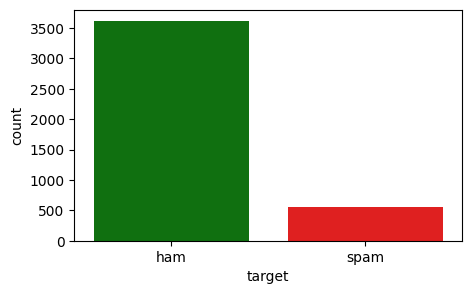

In [4]:
print(df_train.shape, df_test.shape)
# Visualiazation
from seaborn import countplot

# Distribution of the target
print('Distribution of the target:')
print(round(df_train['target'].value_counts(normalize=True) * 100, 2))
plt.rcParams['figure.figsize'] = (5, 3)
labels = sorted(df_train['target'].unique().tolist())
palette = {labels[0]: 'green', labels[1]: 'red'}
countplot(x='target', hue='target', data=df_train, palette=palette)
plt.show()

# Preprocessing

In [5]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [6]:
import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing import sequence

y_train = df_train['target'].astype('category').cat.codes
y_test  = df_test['target'].astype('category').cat.codes

def preprocess_sms(sms):
    sms = re.sub(r'([^\s\w])+', ' ', sms)
    sms = ' '.join([WordNetLemmatizer().lemmatize(word) for word in sms.split()
                    if not word in set(stopwords.words('english'))])
    sms = sms.lower()
    return sms

X_train = df_train['sms'].apply(lambda x: preprocess_sms(x))
X_test = df_test['sms'].apply(lambda x: preprocess_sms(x))

X_train[:5]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/marina/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/marina/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


0    ahhhh woken bad dream u tho dont like u right ...
1                                        never nothing
2    u sound like manky scouse boy steve like trave...
3    mum say wan go go shun bian watch da glass exh...
4    never lei v lazy got wat dat day ü send da url...
Name: sms, dtype: object

In [7]:
# Keep top 1000 frequently occurring words
t = Tokenizer(num_words=1000)
t.fit_on_texts(X_train)

# Transform each text to a sequence of integers
sequences_train = t.texts_to_sequences(X_train)
sequences_test = t.texts_to_sequences(X_test)
# print(sequences_train[:5])

# Make all rows of equal length
# Cut off the words after seeing 500 words in sms
sequences_matrix_train = sequence.pad_sequences(sequences_train, maxlen=500)
sequences_matrix_test = sequence.pad_sequences(sequences_test, maxlen=500)

sequences_matrix_train[:5]

array([[  0,   0,   0, ...,  54, 228,  86],
       [  0,   0,   0, ...,   0, 195, 252],
       [  0,   0,   0, ...,   6, 338, 422],
       [  0,   0,   0, ...,   9, 243,  43],
       [  0,   0,   0, ..., 124,  70,  24]], dtype=int32)

# Model

In [8]:
input_layer = tf.keras.layers.Input(shape=[500]) # maxlen=500
dense_layer = tf.keras.layers.Embedding(1000, 50, input_length=500)(input_layer) # num_words=1000, n, maxlen=500
dense_layer = tf.keras.layers.LSTM(64)(dense_layer)

dense_layer = tf.keras.layers.Dense(256, activation='relu')(dense_layer)
dense_layer = tf.keras.layers.Dropout(0.5)(dense_layer)
dense_layer = tf.keras.layers.Dense(1, activation='relu')(dense_layer)

model = tf.keras.models.Model(inputs=input_layer, outputs=dense_layer)
model.compile(
    loss='binary_crossentropy',
    optimizer='RMSprop',
    metrics=['accuracy']
)
model.summary()

/Users/marina/anaconda3/envs/clean_env/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 500, 50)        │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,337 (376.32 KB)

 Trainable params: 96,337 (376.32 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(sequences_matrix_train,
                    y_train,
                    batch_size=128,
                    epochs=4,
                    validation_split=0.2,
                    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.0001)]
                    )

Epoch 1/4
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - accuracy: 0.8741 - loss: 0.4061 - val_accuracy: 0.9677 - val_loss: 0.1811
Epoch 2/4
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 314ms/step - accuracy: 0.9737 - loss: 0.1179 - val_accuracy: 0.9856 - val_loss: 0.1105
Epoch 3/4
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 316ms/step - accuracy: 0.9895 - loss: 0.0835 - val_accuracy: 0.9868 - val_loss: 0.1341


# Model evaluation

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9870 - loss: 0.0853
Loss: 0.092, Accuracy: 0.986


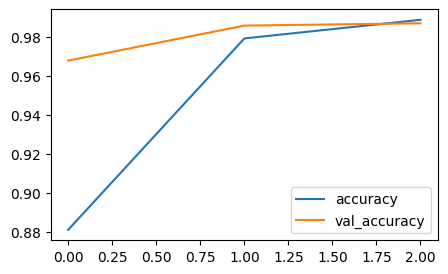

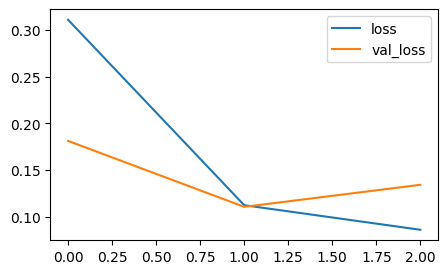

In [10]:
model_evaluation = model.evaluate(sequences_matrix_test, y_test)
print('Loss: {:.3f}, Accuracy: {:.3f}'.format(model_evaluation[0], model_evaluation[1]))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [11]:
# function to predict messages based on model
def predict_message(pred_text):
  sms = pd.Series([pred_text])
  sms = sms.apply(lambda x: preprocess_sms(x))
  sequences = t.texts_to_sequences(sms)
  sequences_matrix = sequence.pad_sequences(sequences, maxlen=500)

  prediction = model.predict(sequences_matrix)[0]
  label = ('ham' if prediction<0.5 else 'spam')
  prediction = [prediction, label]

  return prediction

pred_text = "how are you doing today?"

prediction = predict_message(pred_text)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[array([0.], dtype=float32), 'ham']


In [12]:
# Run this cell to test your function and model. Do not modify contents.
def test_predictions():
  test_messages = ["how are you doing today",
                   "sale today! to stop texts call 98912460324",
                   "i dont want to go. can we try it a different day? available sat",
                   "our new mobile video service is live. just install on your phone to start watching.",
                   "you have won £1000 cash! call to claim your prize.",
                   "i'll bring it tomorrow. don't forget the milk.",
                   "wow, is your arm alright. that happened to me one time too"
                  ]

  test_answers = ["ham", "spam", "ham", "spam", "spam", "ham", "ham"]
  passed = True

  for msg, ans in zip(test_messages, test_answers):
    prediction = predict_message(msg)
    if prediction[1] != ans:
      passed = False

  if passed:
    print("You passed the challenge. Great job!")
  else:
    print("You haven't passed yet. Keep trying.")

test_predictions()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
You passed the challenge. Great job!
